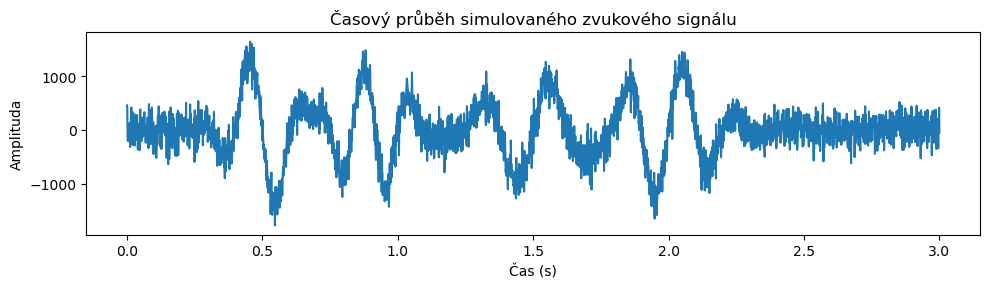

In [6]:
import numpy as np
import matplotlib.pyplot as plt

sr = 1000 
duration = 3 
t = np.linspace(0, duration, sr * duration)

signal = (
    1500 * np.sin(2 * np.pi * 5 * t) * np.exp(-((t - 0.5) ** 2) / 0.02) +
    1200 * np.sin(2 * np.pi * 6 * t) * np.exp(-((t - 0.9) ** 2) / 0.03) +
    1000 * np.sin(2 * np.pi * 4 * t) * np.exp(-((t - 1.5) ** 2) / 0.05) +
    1300 * np.sin(2 * np.pi * 5 * t) * np.exp(-((t - 2.0) ** 2) / 0.04)
)


noise = 200 * np.random.randn(len(t))
signal += noise

# Vykreslení
plt.figure(figsize=(10, 3))
plt.plot(t, signal)
plt.xlabel("Čas (s)")
plt.ylabel("Amplituda")
plt.title("Časový průběh simulovaného zvukového signálu")
plt.tight_layout()

plt.savefig("Časový průběh simulovaného zvukového signálu.png", dpi=300)
plt.show()


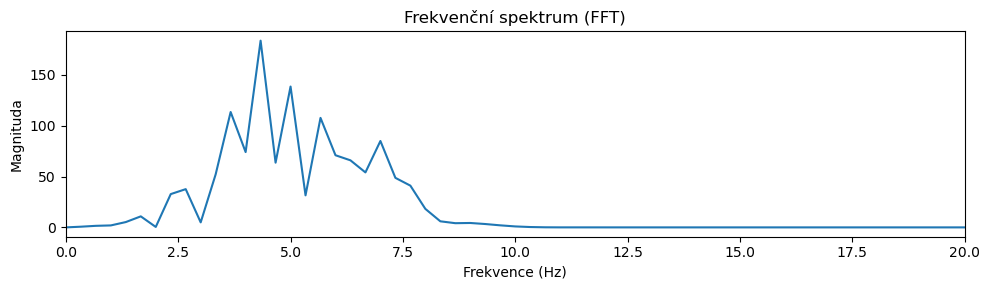

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parametry signálu
sr = 1000  # vzorkovací frekvence (Hz)
duration = 3
t = np.linspace(0, duration, sr * duration)

# Stejný simulovaný signál jako předtím
signal = (
    1500 * np.sin(2 * np.pi * 5 * t) * np.exp(-((t - 0.5) ** 2) / 0.02) +
    1200 * np.sin(2 * np.pi * 6 * t) * np.exp(-((t - 0.9) ** 2) / 0.03) +
    1000 * np.sin(2 * np.pi * 4 * t) * np.exp(-((t - 1.5) ** 2) / 0.05) +
    1300 * np.sin(2 * np.pi * 5 * t) * np.exp(-((t - 2.0) ** 2) / 0.04)
)

# FFT
N = len(signal)
fft_values = np.fft.fft(signal)
fft_values = np.abs(fft_values) / N  # normalizace

# Frekvenční osa
freqs = np.fft.fftfreq(N, d=1/sr)

# Pouze kladné frekvence
mask = freqs >= 0
freqs = freqs[mask]
fft_values = fft_values[mask]

# Vykreslení
plt.figure(figsize=(10, 3))
plt.plot(freqs, fft_values)
plt.xlabel("Frekvence (Hz)")
plt.ylabel("Magnituda")
plt.title("Frekvenční spektrum (FFT)")
plt.xlim(0, 20)  # omezíme na nízké frekvence pro přehlednost
plt.tight_layout()

# Uložení
plt.savefig("Frekvenční spektrum.png", dpi=300)
plt.show()

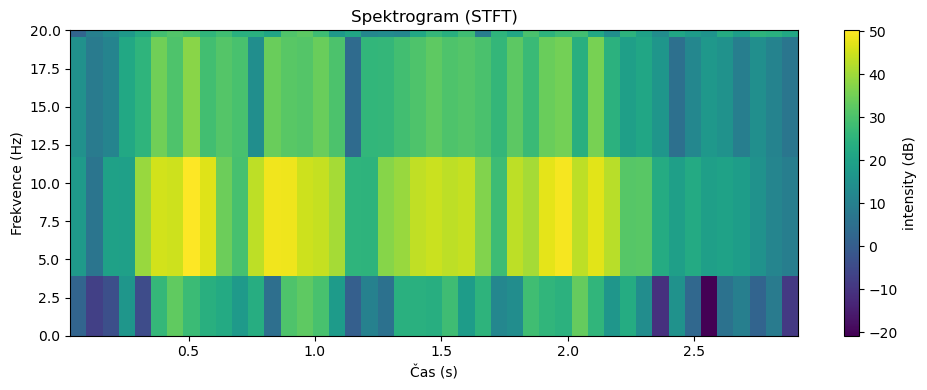

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# Parametry signálu
sr = 1000  # vzorkovací frekvence (Hz)
duration = 3
t = np.linspace(0, duration, sr * duration)

# Stejný simulovaný signál jako předtím
signal = (
    1500 * np.sin(2 * np.pi * 5 * t) * np.exp(-((t - 0.5) ** 2) / 0.02) +
    1200 * np.sin(2 * np.pi * 6 * t) * np.exp(-((t - 0.9) ** 2) / 0.03) +
    1000 * np.sin(2 * np.pi * 4 * t) * np.exp(-((t - 1.5) ** 2) / 0.05) +
    1300 * np.sin(2 * np.pi * 5 * t) * np.exp(-((t - 2.0) ** 2) / 0.04)
)

# Přidání šumu
signal += 200 * np.random.randn(len(t))

# Výpočet spektrogramu
f, t_spec, Sxx = spectrogram(signal, fs=sr, nperseg=128, noverlap=64)

# Vykreslení
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10))
plt.ylabel("Frekvence (Hz)")
plt.xlabel("Čas (s)")
plt.title("Spektrogram (STFT)")
plt.colorbar(label="intensity (dB)")
plt.ylim(0, 20)  # pro přehlednost nízké frekvence
plt.tight_layout()

# Uložení
plt.savefig("Spektrogram.png", dpi=300)
plt.show()